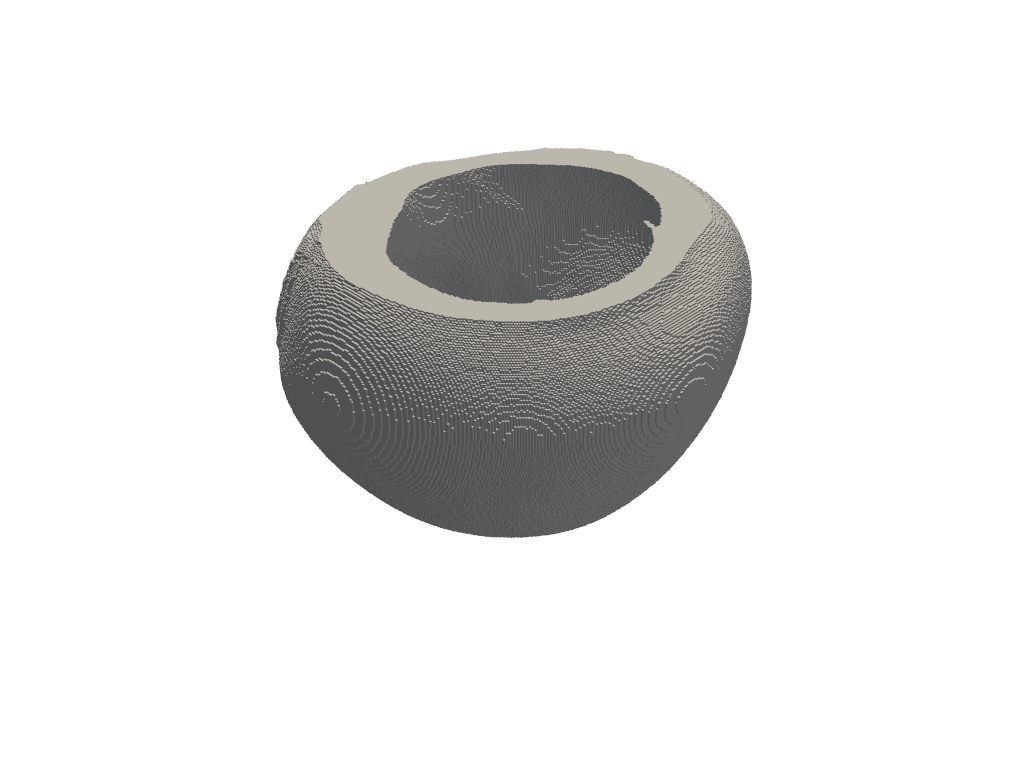

In [1]:
from pathlib import Path
import numpy as np
import pyvista as pv
import finitewave as fw


path = Path("./data")
mesh = np.load(path / "lv_mesh.npy")

grid = fw.PyVistaMeshGrid(mesh)

pv.set_jupyter_backend("static")
pl = pv.Plotter()
pl.add_mesh(grid, color="lightgray", opacity=1.)
pl.show()

## Add layer to solver problems with gradient calculation later

In [2]:
from scipy import ndimage


def extract_surface(mesh):
    # check if mesh is touched by the boundary of the volume
    if (np.any([mesh[i, :, :].any() for i in [0, -1]])
        or np.any([mesh[:, i, :].any() for i in [0, -1]])
        or np.any([mesh[:, :, i].any() for i in [0, -1]])):
        raise ValueError("Mesh touches the boundary of the volume. "
                         "Cannot dilate mesh to create outer surface.")

    dilated_mesh = ndimage.binary_dilation(mesh > 0)
    surface = dilated_mesh & (mesh == 0)
    return surface, dilated_mesh


surface, dilated_mesh = extract_surface(mesh)
full_coords = np.argwhere(dilated_mesh > 0)
full_indices = np.flatnonzero(dilated_mesh > 0)
index_map = - np.ones_like(dilated_mesh, dtype=np.int32)
index_map[dilated_mesh > 0] = np.arange(full_indices.size, dtype=np.int32)

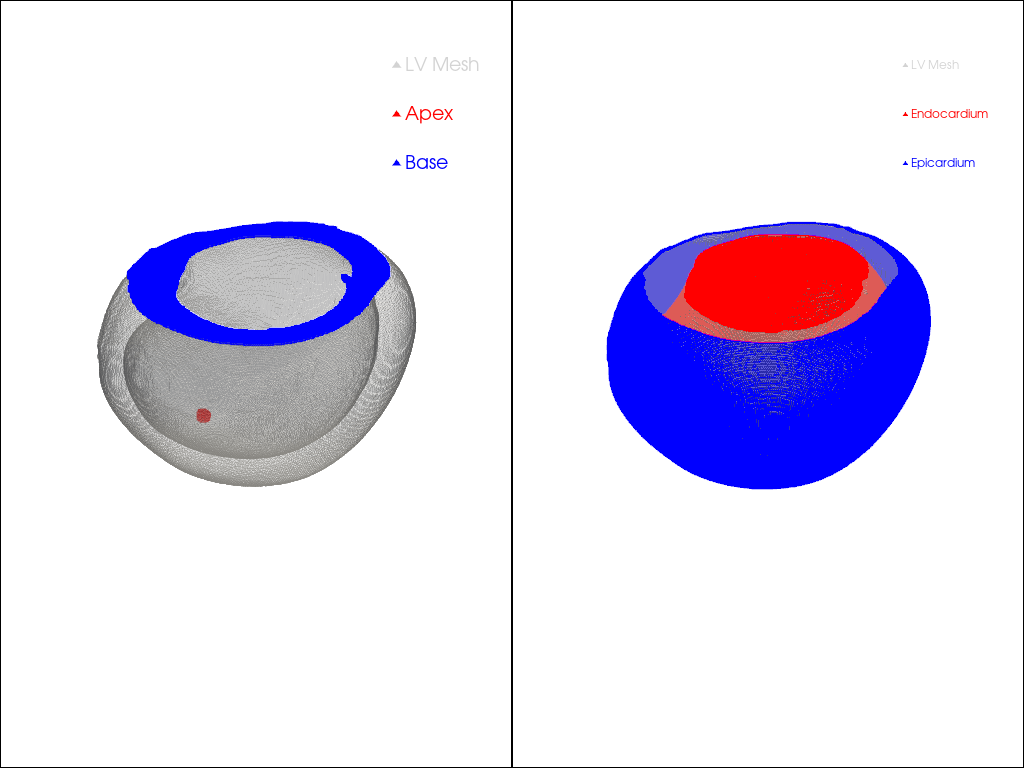

In [3]:
from scipy import ndimage, spatial


def extract_endo_epi_indices(surface, index_map):

    surface_labeled, n_surfaces = ndimage.label(surface > 0, structure=np.ones((3, 3, 3)))
    if n_surfaces != 2:
        raise ValueError(f"Expected 2 surfaces, but found {n_surfaces}.")

    endo_indices = np.flatnonzero(surface_labeled == 2)
    endo_indices = index_map.flat[endo_indices]

    if np.any(endo_indices < 0):
        raise ValueError("Some endocardial indices are out of bounds.")

    epi_indices = np.flatnonzero(surface_labeled == 1)
    epi_indices = index_map.flat[epi_indices]
    if np.any(epi_indices < 0):
        raise ValueError("Some epicardial indices are out of bounds.")

    return endo_indices, epi_indices


def extract_apex_indices(surface, apex_center, index_map, apex_size=5):
    surface_coords = np.argwhere(surface > 0)

    tree = spatial.KDTree(surface_coords)
    apex_on_surface = tree.query_ball_point(np.atleast_2d(apex_center), apex_size)

    apex_coords = surface_coords[np.concatenate(apex_on_surface)]
    apex_indices = index_map[tuple(apex_coords.T)]

    if np.any(apex_indices < 0):
        raise ValueError("Some apex indices are out of bounds.")
    return apex_indices


def extract_base_indices(base_coords, index_map):
    base_indices = index_map[tuple(base_coords.T)]
    if np.any(base_indices < 0):
        raise ValueError("Some base indices are out of bounds.")
    return base_indices


apex_center = np.array([102, 35, 15], dtype=np.int64)
apex_indices = extract_apex_indices(surface, apex_center, index_map, apex_size=5)

base_coords = full_coords[full_coords[:, 2] == full_coords[:, 2].max()]
base_indices = extract_base_indices(base_coords, index_map)

surface_without_base = surface.copy()
surface_without_base[tuple(base_coords.T)] = 0

endo_indices, epi_indices = extract_endo_epi_indices(surface_without_base, index_map)

pv.set_jupyter_backend("static")
pl = pv.Plotter(shape=(1, 2))
pl.subplot(0, 0)
pl.add_mesh(grid, color="lightgray", opacity=0.2, label="LV Mesh")
pl.add_points(full_coords[apex_indices].astype(np.float32), color="red", point_size=5, label="Apex")
pl.add_points(full_coords[base_indices].astype(np.float32), color="blue", point_size=5, label="Base")
pl.add_legend()
pl.subplot(0, 1)
pl.add_mesh(grid, color="lightgray", opacity=0.5, label="LV Mesh")
pl.add_points(full_coords[endo_indices].astype(np.float32), color="red", point_size=5, label="Endocardium")
pl.add_points(full_coords[epi_indices].astype(np.float32), color="blue", point_size=5, label="Epicardium")
pl.add_legend()
pl.link_views()
pl.show()

In [4]:
tissue = fw.CardiacTissue(dilated_mesh.shape, dr=.2)
tissue.mesh = dilated_mesh.astype(np.uint8)

diffusion_model = fw.IsotropicDiscretization()
K, M = diffusion_model.compute_weights(tissue)

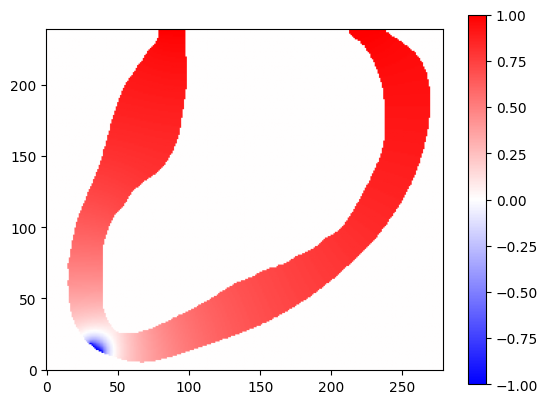

In [5]:
import matplotlib.pyplot as plt
from finitewave_tools.linalg.linalg import make_system, linear_solver

apex_base_boundaries = [(apex_indices, -1), (base_indices, 1)]

K_apex_base, b_apex_base, x0, inds = make_system(K, dirichlet_conditions=apex_base_boundaries)

apex_base_laplace = x0
apex_base_laplace[inds] = linear_solver(K_apex_base, b_apex_base, x0=x0[inds])

apex_base_mesh = np.zeros_like(dilated_mesh, dtype=np.float64)
apex_base_mesh.flat[full_indices] = apex_base_laplace.astype(np.float64)

plt.figure()
plt.imshow(apex_base_mesh[apex_center[0]].T, cmap="bwr", origin="lower")
plt.colorbar()
plt.show()

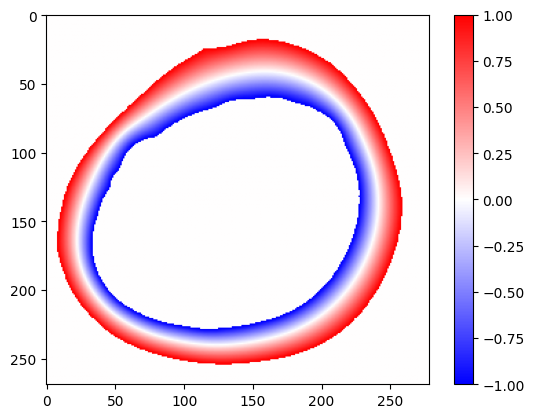

In [6]:
endo_epi_boundaries = [(endo_indices, -1), (epi_indices, 1)]

K_endo_epi, b_endo_epi, x0, inds = make_system(K, dirichlet_conditions=endo_epi_boundaries)

endo_epi_laplace = x0
endo_epi_laplace[inds] = linear_solver(K_endo_epi, b_endo_epi, x0=x0[inds])
endo_epi_mesh = np.zeros_like(dilated_mesh, dtype=np.float64)
endo_epi_mesh.flat[full_indices] = endo_epi_laplace.astype(np.float64)

%matplotlib inline
plt.figure()
plt.imshow(endo_epi_mesh[:, :, endo_epi_mesh.shape[2]//2], cmap="bwr")
plt.colorbar()
plt.show()

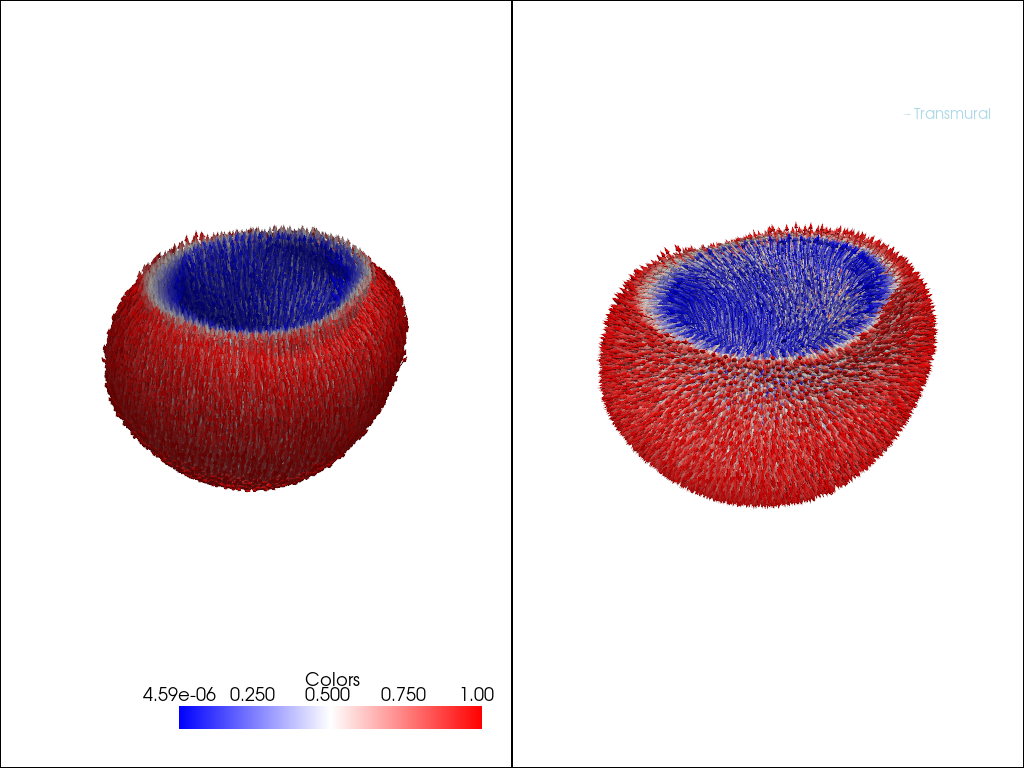

In [59]:
from finitewave_tools.fibers.fdm.gradient import compute_gradient, normalize_vectors
from finitewave_tools.fibers.fdm.sampling import sample_from_layers


def build_arrows(coords, vectors, colors, scale_factor=5):
    mesh = pv.PolyData(coords * 0.25)
    mesh.point_data["Vectors"] = vectors
    mesh.point_data["Colors"] = colors

    arrows = mesh.glyph(
        orient="Vectors", 
        scale=False,  
        factor=scale_factor
    )
    return arrows


apex_base_grad = compute_gradient(apex_base_mesh, normalize=True, mask=mesh > 0)
endo_epi_grad = compute_gradient(endo_epi_mesh, normalize=True, mask=mesh > 0)

coords = np.argwhere(mesh > 0)
n_layers = 10
endo_epi_dist = endo_epi_mesh[mesh > 0]
endo_epi_dist = (endo_epi_dist - endo_epi_dist.min()) / (endo_epi_dist.max() - endo_epi_dist.min())
endo_epi_layers = np.digitize(endo_epi_dist, bins=np.linspace(0, 1, n_layers + 1))

sampled_ids = sample_from_layers(endo_epi_layers, coords, 5)
selected_coords = coords[sampled_ids]
endo_epi_vec = endo_epi_grad[sampled_ids]
apex_base_vec = apex_base_grad[sampled_ids]
colors = endo_epi_dist[sampled_ids]

pv.set_jupyter_backend("static")
pl = pv.Plotter(shape=(1, 2))
pl.subplot(0, 0)
# pl.add_mesh(grid, color="lightgray", opacity=1.0, label="LV Mesh")
pl.add_mesh(build_arrows(selected_coords, apex_base_vec, colors, scale_factor=5), 
            scalars="Colors", cmap="bwr", label="Apex-Base")
pl.subplot(0, 1)
# pl.add_mesh(grid, color="lightgray", opacity=1.0, label="LV Mesh")
pl.add_mesh(build_arrows(selected_coords, endo_epi_vec, colors, scale_factor=5),
            scalars="Colors", cmap="bwr", label="Transmural")
pl.add_legend()
pl.link_views()
pl.show()

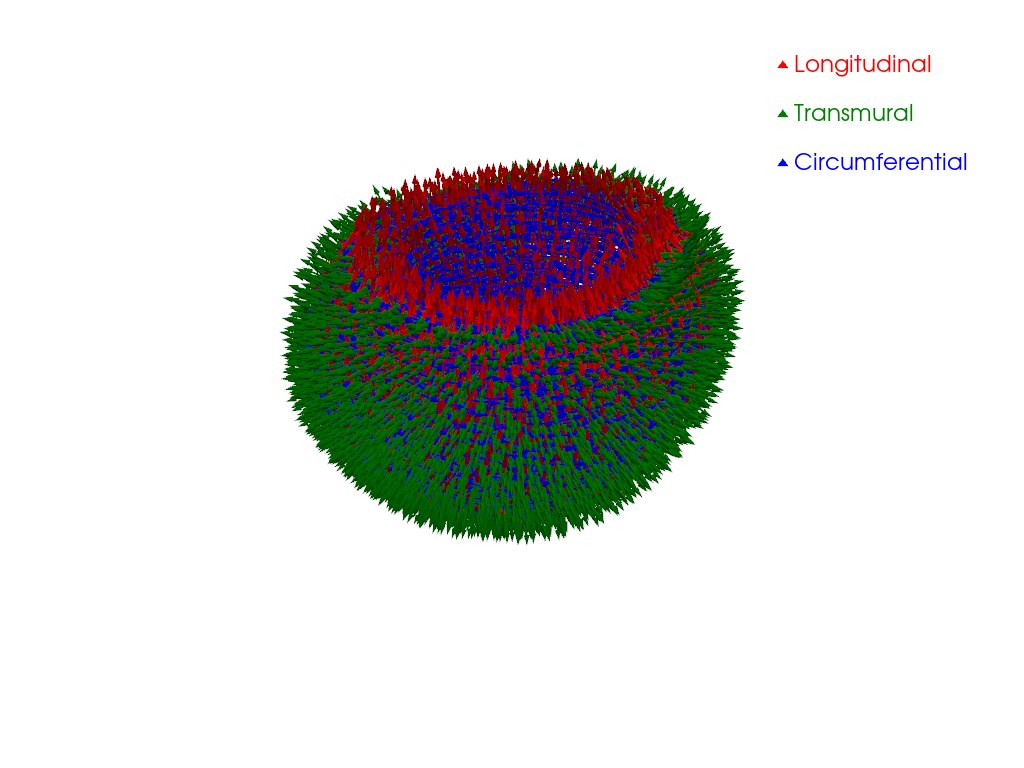

In [60]:
from finitewave_tools.fibers.fdm.coordinate_system import (
    build_coord_system
)
e0, e1, e2 = build_coord_system(apex_base_grad, endo_epi_grad)

sampled_ids = sample_from_layers(endo_epi_layers, coords, 10)
selected_coords = coords[sampled_ids]

e0_vec = e0[sampled_ids]
e1_vec = e1[sampled_ids]
e2_vec = e2[sampled_ids]

pv.set_jupyter_backend("static")
pl = pv.Plotter()
# pl.add_mesh(grid, color="lightgray", opacity=1.0)
pl.add_arrows(selected_coords, e0_vec, mag=20, color="red", label="Longitudinal")
pl.add_arrows(selected_coords, e1_vec, mag=20, color="green", label="Transmural")
pl.add_arrows(selected_coords, e2_vec, mag=20, color="blue", label="Circumferential")
pl.add_legend()
pl.show()

## Generate Fibers

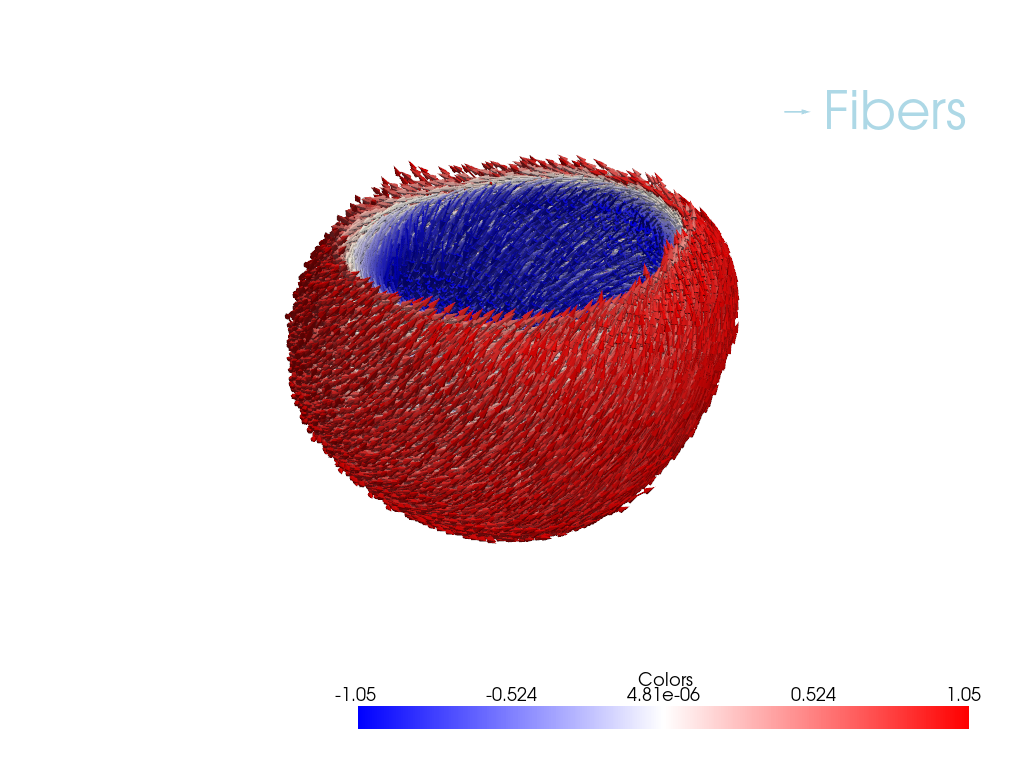

In [61]:
from finitewave_tools.fibers.rule_based_fibers import (
    rule_based_fibers,
    fiber_angles
)

alpha = fiber_angles(endo_epi_dist, alpha_endo=-np.pi/3, alpha_epi=np.pi/3)
beta = np.zeros_like(alpha)

fibers = rule_based_fibers(e0, e1, e2, alpha, beta)

endo_epi_layers = np.digitize(endo_epi_dist, bins=np.linspace(0, 1, n_layers + 1))
sampled_ids = sample_from_layers(endo_epi_layers, coords, 5)

selected_coords = coords[sampled_ids]
colors = alpha[sampled_ids]

fiber_arrows = build_arrows(selected_coords, fibers[sampled_ids], colors, scale_factor=5)

pv.set_jupyter_backend("static")
pl = pv.Plotter()
pl.add_mesh(fiber_arrows, scalars="Colors", cmap="bwr", label="Fibers")
pl.add_legend()
pl.show()